# Nebular Emission

Nebular emission (recombination lines + free-free/bound-free continuum)
contributes significantly to galaxy photometry, especially at high
redshift where strong emission lines fall into broadband filters.

tengri provides three nebular backends:

1. **BakedIn**: SSP templates with nebular emission pre-computed at
   fixed ionization parameter and gas metallicity. Zero extra parameters.
2. **CloudyGrid**: Pre-computed CLOUDY photoionization grids with free
   $\log U$ and gas metallicity. Lines + continuum via interpolation.
3. **Cue**: Neural net emulator (Li et al. 2025) with 12 free parameters
   including abundance ratios. Pure JAX, JIT-compatible.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fixed,
    Model,
    ParamSpec,
    load_ssp_data,
)
from tengri.models.nebular import BakedInBackend

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, SPECTRAL_FEATURES, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

## 1. BakedIn Backend: Default Nebular Emission

The default SSP files (`wNE` = with Nebular Emission) include nebular
emission pre-computed at fixed $\log U = -3.0$ and solar gas metallicity.
This is the simplest option: no extra free parameters.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# SED with baked-in nebular emission (default)
spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Fixed(1.5),
    sfh_tsnorm_peak_lbt_gyr=Fixed(0.5),
    sfh_tsnorm_width_gyr=Fixed(0.5),
    sfh_tsnorm_skew=Fixed(0.0),
    sfh_tsnorm_trunc=Fixed(5.0),
    met_logzsol=Fixed(-0.3),
    dust_tau_bc=Fixed(0.0),
    dust_tau_diff=Fixed(0.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.0),
)
model = Model(spec, ssp_data)
params = {
    "sfh_tsnorm_log_peak_sfr": 1.5,
    "sfh_tsnorm_peak_lbt_gyr": 0.5,
    "sfh_tsnorm_width_gyr": 0.5,
    "sfh_tsnorm_skew": 0.0,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.0,
    "dust_tau_diff": 0.0,
    "dust_slope": -0.7,
    "redshift": 0.0,
}
sed_with_neb = model.predict_sed(params)
wave = ssp_data.ssp_wave

W0321 13:23:10.594249 14669199 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 2. Key Emission Lines

Strong emission lines visible in the SED: Ly-alpha, H-beta, [O III],
H-alpha. These lines encode information about ionizing flux, gas
metallicity, and dust.

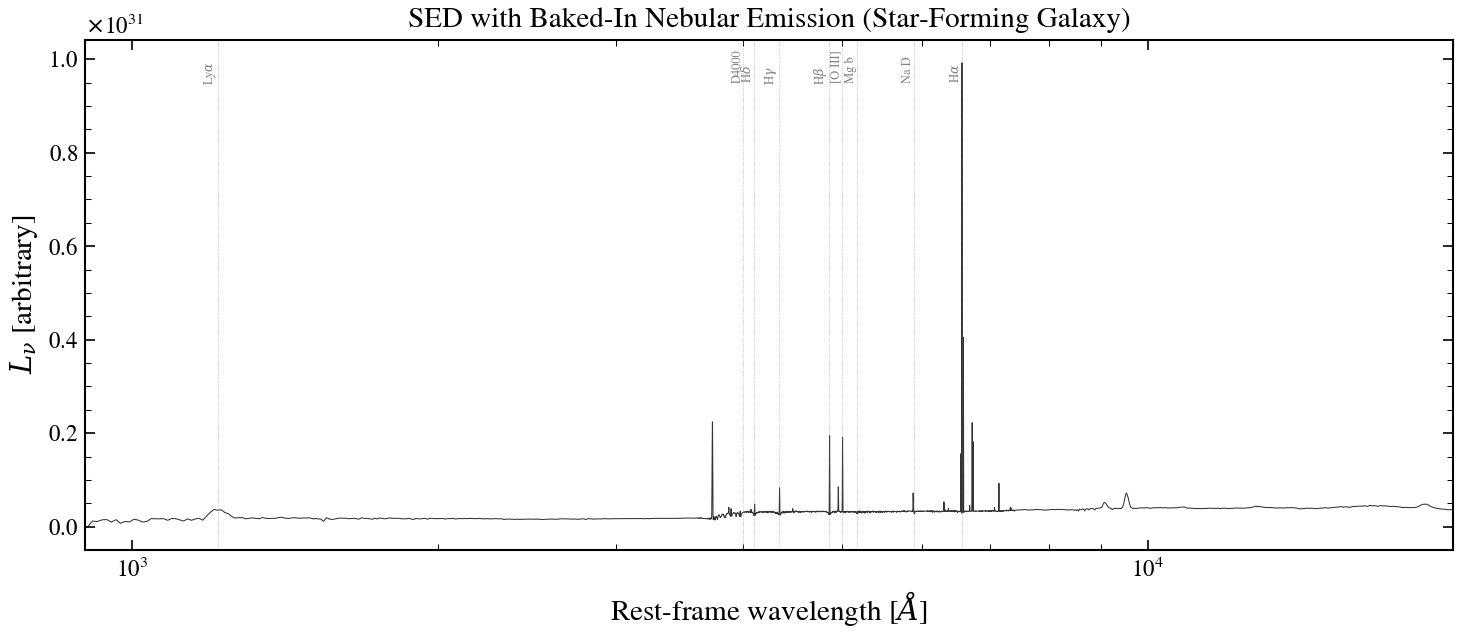

In [3]:
# --- FIGURE 1: Full SED with emission line labels ---
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.array(wave), np.array(sed_with_neb), "k-", lw=0.5, alpha=0.8)

# Mark spectral features
for name, wave_line in SPECTRAL_FEATURES.items():
    if 900 < wave_line < 10000:
        ax.axvline(wave_line, ls=":", color="grey", lw=0.4, alpha=0.6)
        ax.annotate(
            name,
            xy=(wave_line, 0.92),
            xycoords=("data", "axes fraction"),
            fontsize=6,
            rotation=90,
            ha="right",
            color="grey",
        )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [arbitrary]")
ax.set_title("SED with Baked-In Nebular Emission (Star-Forming Galaxy)")
ax.set_xscale("log")
ax.set_xlim(900, 20000)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_sed_nebular.png"), bbox_inches="tight")
plt.show()

## 3. Emission Line Zoom: Optical Region

The optical window contains the strongest diagnostic lines for SED
fitting: H-beta (4861 A), [O III] doublet (4959, 5007 A), H-alpha
(6563 A), and [N II] (6548, 6583 A).

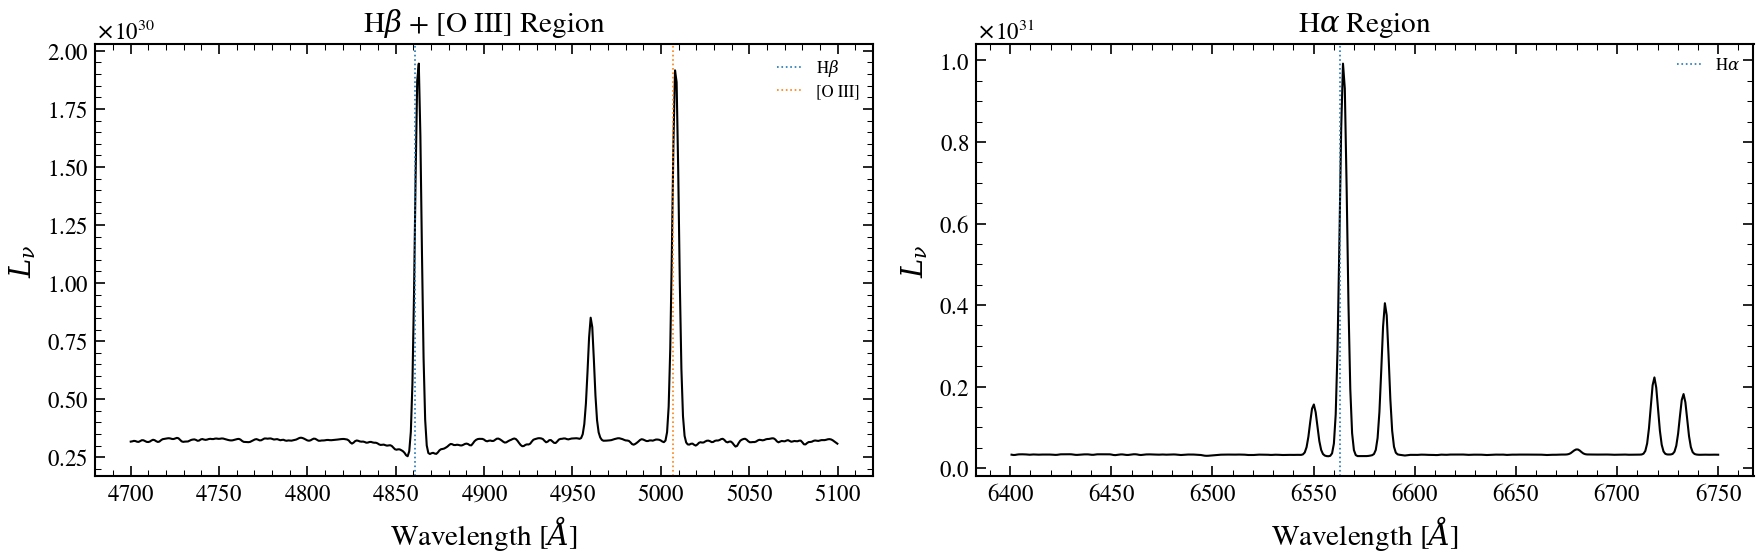

In [4]:
# --- FIGURE 2: Optical emission line zoom ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: H-beta + [O III] region
ax = axes[0]
mask = (wave > 4700) & (wave < 5100)
ax.plot(np.array(wave[mask]), np.array(sed_with_neb[mask]), "k-", lw=1.0)
ax.axvline(4861, ls=":", color=COLORS["rt"], lw=0.8, label=r"H$\beta$")
ax.axvline(5007, ls=":", color=COLORS["geovi"], lw=0.8, label="[O III]")
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$")
ax.set_title(r"H$\beta$ + [O III] Region")
ax.legend(fontsize=8, frameon=False)

# Right: H-alpha region
ax = axes[1]
mask = (wave > 6400) & (wave < 6750)
ax.plot(np.array(wave[mask]), np.array(sed_with_neb[mask]), "k-", lw=1.0)
ax.axvline(6563, ls=":", color=COLORS["rt"], lw=0.8, label=r"H$\alpha$")
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$")
ax.set_title(r"H$\alpha$ Region")
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_emission_line_zoom.png"), bbox_inches="tight")
plt.show()

## 4. Backend Comparison Table

| Backend | Free params | Speed | Flexibility | Data needed |
|---------|------------|-------|-------------|-------------|
| BakedIn | 0 | Fastest | None (fixed logU, Z) | SSP `wNE` file |
| CloudyGrid | 2 (logU, Z_gas) | Fast | Moderate | CLOUDY HDF5 grid |
| Cue | 12 | Moderate | Full (abundances) | Neural net weights |

For most photometric fitting, BakedIn is sufficient. CloudyGrid adds
ionization parameter freedom for spectroscopic fitting. Cue provides
the most flexibility for detailed abundance studies.

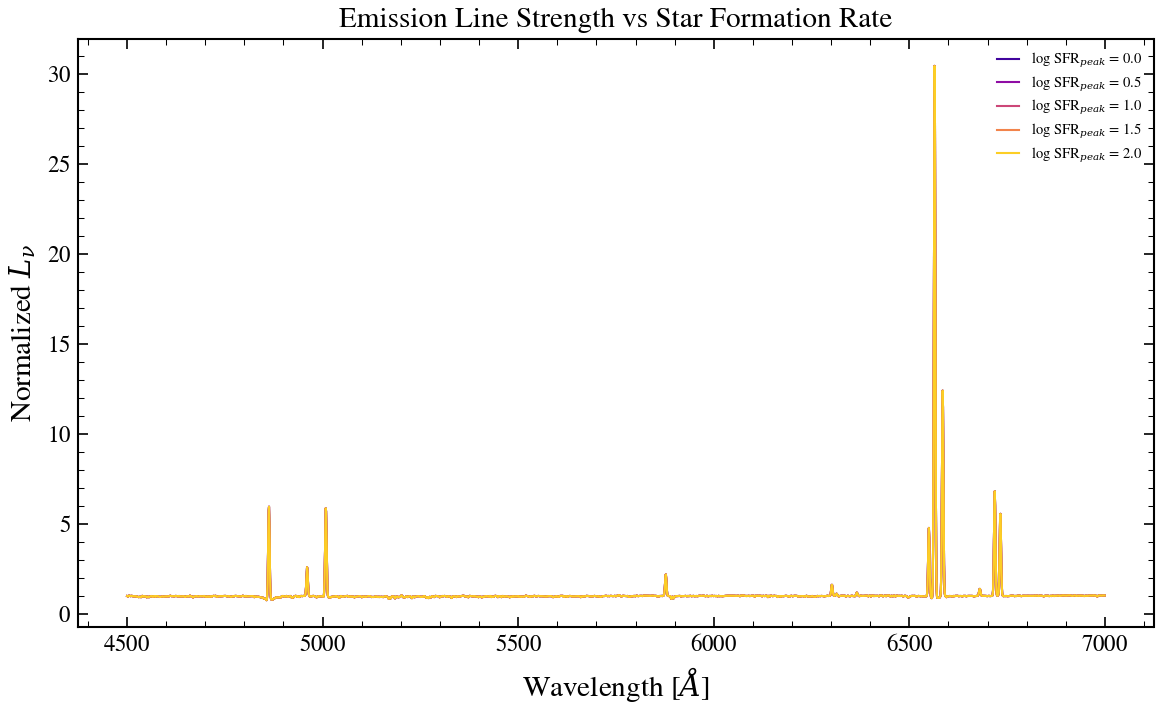

In [5]:
# --- FIGURE 3: SFR dependence of emission lines ---
# Show how the emission line EW changes with SFR (using different peak SFRs)
fig, ax = plt.subplots(figsize=(8, 5))

log_peak_sfrs = [0.0, 0.5, 1.0, 1.5, 2.0]
sfr_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(log_peak_sfrs)))

for log_sfr, color in zip(log_peak_sfrs, sfr_colors):
    params_var = dict(params)
    params_var["sfh_tsnorm_log_peak_sfr"] = log_sfr
    sed_var = model.predict_sed(params_var)
    # Normalize at 5500 A
    idx_norm = int(jnp.argmin(jnp.abs(wave - 5500.0)))
    sed_norm = sed_var / sed_var[idx_norm]
    mask = (wave > 4500) & (wave < 7000)
    ax.plot(
        np.array(wave[mask]),
        np.array(sed_norm[mask]),
        color=color,
        lw=1.0,
        label=f"log SFR$_{{peak}}$ = {log_sfr}",
    )

ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"Normalized $L_\nu$")
ax.set_title("Emission Line Strength vs Star Formation Rate")
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_eline_vs_sfr.png"), bbox_inches="tight")
plt.show()

## Summary

Nebular emission is critical for accurate SED fitting, especially for:
- Young, star-forming galaxies with strong emission lines
- High-redshift galaxies where lines fall in photometric bands
- Spectroscopic fitting where line shapes carry physical information

The BakedIn backend requires no extra data files and is the recommended
starting point. Switch to CloudyGrid or Cue when you need to fit
ionization parameter or detailed abundances.